# 01 — Limpeza do SINAN (Dengue 2025)

**Projeto Aplicado II — Guilherme Cunha Oliveira (RA 10754621) e Gabriel Lucca Simionato (RA 10751300)**

Notebook organizado conforme a seção 7 do *Plano de Limpeza das Bases*: objetivo, bibliotecas, caminhos, carregamento, diagnóstico inicial, regras de limpeza, aplicação, validação, exportação e resumo. O arquivo bruto em `db/bases_brutas/` não é alterado em nenhum momento; toda saída vai para `db/bases_tratadas/sinan/`.

## 1. Objetivo

Preparar a base principal do projeto — as notificações de dengue de 2025 do SINAN — para a análise e a modelagem, seguindo a seção 3 do plano: diagnosticar a base sem alterá-la, decidir coluna a coluna o que sai e o que fica, construir o alvo a partir de `CLASSI_FIN` registrando cada exclusão, separar em uma cópia de auditoria os campos que revelam o desfecho (prevenção de *leakage*), tratar ausências e códigos de ignorado pelo significado de cada campo, converter datas, investigar duplicidades antes de qualquer remoção e exportar uma base tratada, rastreável e com uma linha por caso elegível.

In [1]:
# ============================================================
# 1. OBJETIVO
# ============================================================
ENTRADA_PREVISTA = "db/bases_brutas/sinan/dados/DENGBR25.csv"
SAIDA_PREVISTA   = "db/bases_tratadas/sinan/sinan_dengue_2025_tratado.csv"

## 2. Bibliotecas

pandas e NumPy para leitura e transformação; `hashlib` para a identidade do arquivo e para a detecção de linhas duplicadas por *hash*; `pathlib`, `json` e `time` da biblioteca padrão. Matplotlib entra apenas para um gráfico de diagnóstico.

In [2]:
# ============================================================
# 2. BIBLIOTECAS
# ============================================================
import sys, platform, json, hashlib, gc, time, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore"); plt.rcParams.update({"axes.grid": True, "grid.alpha": .3})
pd.set_option("display.width", 160, "display.max_columns", 60, "display.max_rows", 150)
print("Python", platform.python_version(), "| pandas", pd.__version__, "| numpy", np.__version__)

Python 3.12.3 | pandas 3.0.2 | numpy 2.4.4


## 3. Caminhos

Os caminhos são relativos à raiz do repositório. A camada bruta é somente leitura; a camada tratada recebe a base tratada, a cópia de auditoria, a tabela de decisão por coluna, o dicionário da base tratada e o registro (log) da execução.

In [3]:
# ============================================================
# 3. CAMINHOS
# ============================================================
RAIZ = Path("..").resolve()
BRUTA   = RAIZ/"db/bases_brutas/sinan/dados"
TRATADA = RAIZ/"db/bases_tratadas/sinan"
TRATADA.mkdir(parents=True, exist_ok=True)

ARQ_BRUTO          = BRUTA/"DENGBR25.csv"
ARQ_TRATADO        = TRATADA/"sinan_dengue_2025_tratado.csv"
ARQ_AUDITORIA      = TRATADA/"sinan_dengue_2025_auditoria.csv"
ARQ_DECISAO_COLS   = TRATADA/"sinan_colunas_decisao.csv"
ARQ_DICIONARIO     = TRATADA/"sinan_dengue_2025_tratado_dicionario.csv"
ARQ_LOG            = TRATADA/"sinan_limpeza_log.json"
LOG = {"entrada": str(ARQ_BRUTO.relative_to(RAIZ)), "saida": str(ARQ_TRATADO.relative_to(RAIZ)), "etapas": {}}
print("entrada:", ARQ_BRUTO.relative_to(RAIZ), "| existe:", ARQ_BRUTO.exists())

entrada: db/bases_brutas/sinan/dados/DENGBR25.csv | existe: True


## 4. Carregamento

O arquivo tem 457 MB e 121 colunas; carregar tudo com tipos inferidos não cabe na memória do ambiente. Por isso o carregamento acontece em dois momentos, sempre em modo leitura:

1. **Passagem de diagnóstico (seção 5)** — o arquivo inteiro é percorrido em blocos de 100 mil linhas, com todas as 121 colunas lidas como texto, apenas para contar nulos, códigos e duplicidades. Nada é guardado além dos contadores.
2. **Carregamento das colunas retidas (seção 7)** — só as colunas aprovadas nas regras da seção 6 são carregadas, com tipos compactos.

Nesta seção registramos a identidade do arquivo (tamanho, hash SHA-256), detectamos codificação e separador a partir dos primeiros bytes e lemos uma amostra para inspecionar os tipos inferidos.

In [4]:
# ============================================================
# 4. CARREGAMENTO
# ============================================================
def sha256(caminho, bloco=1 << 24):
    h = hashlib.sha256()
    with open(caminho, "rb") as f:
        for parte in iter(lambda: f.read(bloco), b""): h.update(parte)
    return h.hexdigest()

t0 = time.time()
cabecalho = open(ARQ_BRUTO, "rb").read(4096)
bom = cabecalho.startswith(b"\xef\xbb\xbf")
try:
    cabecalho.decode("utf-8"); encoding = "utf-8-sig" if bom else "utf-8"
except UnicodeDecodeError:
    encoding = "latin-1"
primeira = cabecalho.split(b"\n")[0]
separador = max([",", ";", "\t", "|"], key=lambda s: primeira.count(s.encode()))
LOG["etapas"]["identidade"] = {"tamanho_MB": round(ARQ_BRUTO.stat().st_size/1e6, 1), "sha256": sha256(ARQ_BRUTO),
                               "encoding": encoding, "separador": separador, "bom": bom}
print(json.dumps(LOG["etapas"]["identidade"], indent=2), f"\n({time.time()-t0:.0f} s)")

{
  "tamanho_MB": 456.8,
  "sha256": "2b89c57121d49c0352eebf5220e0e5528ae28341d707a254803c64c60ecf3a51",
  "encoding": "utf-8",
  "separador": ",",
  "bom": false
} 
(2 s)


In [5]:
amostra = pd.read_csv(ARQ_BRUTO, sep=separador, encoding=encoding, nrows=200_000, low_memory=False)
print("amostra:", amostra.shape)
tipos_inferidos = pd.DataFrame({"dtype_inferido": amostra.dtypes.astype(str),
                                "nulos_%_amostra": (amostra.isna().mean()*100).round(1),
                                "n_distintos_amostra": amostra.nunique(),
                                "exemplo": amostra.iloc[0].astype(str).str[:12]})
tipos_inferidos

amostra: (200000, 121)


,dtype_inferido,nulos_%_amostra,n_distintos_amostra,exemplo
TP_NOT,int64,0.0,1,2
ID_AGRAVO,str,0.0,1,A90
DT_NOTIFIC,str,0.0,501,2024-12-29
SEM_NOT,int64,0.0,78,202501
NU_ANO,int64,0.0,3,2024
SG_UF_NOT,int64,0.0,27,32
ID_MUNICIP,int64,0.0,1294,320070
ID_REGIONA,int64,0.0,205,32004
ID_UNIDADE,float64,0.1,6530,2485397.0
DT_SIN_PRI,str,0.0,371,2024-12-29


## 5. Diagnóstico inicial

Seguindo o item 3.1 do plano, a passagem completa pelo arquivo calcula, para as 121 colunas: número de linhas, ausências (quantidade e percentual), códigos efetivamente presentes em `CLASSI_FIN`, nas variáveis clínicas e nas demográficas, linhas totalmente duplicadas e as datas. As linhas duplicadas são detectadas pelo *hash* da linha bruta (os 121 campos idênticos, byte a byte), o que não exige guardar o conteúdo.

In [6]:
# ============================================================
# 5. DIAGNÓSTICO INICIAL
# ============================================================
t0 = time.time()
COLS_CODIGO = ["CLASSI_FIN","CRITERIO","EVOLUCAO","HOSPITALIZ","TPAUTOCTO","CS_SEXO","CS_GESTANT","CS_RACA","CS_ESCOL_N","TP_NOT","ID_AGRAVO","NU_ANO",
               "FEBRE","MIALGIA","CEFALEIA","EXANTEMA","VOMITO","NAUSEA","DOR_COSTAS","CONJUNTVIT","ARTRITE","ARTRALGIA","PETEQUIA_N","LEUCOPENIA","LACO","DOR_RETRO",
               "DIABETES","HEMATOLOG","HEPATOPAT","RENAL","HIPERTENSA","ACIDO_PEPT","AUTO_IMUNE"]
nulos = None; total = 0; codigos = {c: Counter() for c in COLS_CODIGO}
datas_min, datas_max = {}, {}
for bloco in pd.read_csv(ARQ_BRUTO, sep=separador, encoding=encoding, dtype=str, chunksize=100_000):
    total += len(bloco)
    n = bloco.isna().sum(); nulos = n if nulos is None else nulos + n
    for c in COLS_CODIGO: codigos[c].update(bloco[c].fillna("<nulo>").value_counts().to_dict())
    for c in ["DT_NOTIFIC","DT_SIN_PRI","DT_ENCERRA","DT_DIGITA"]:
        d = pd.to_datetime(bloco[c], errors="coerce")
        datas_min[c] = min(datas_min.get(c, d.min()), d.min()); datas_max[c] = max(datas_max.get(c, d.max()), d.max())
diag_nulos = pd.DataFrame({"nulos": nulos, "nulos_%": (nulos/total*100).round(2)}).sort_values("nulos_%", ascending=False)
print(f"linhas: {total:,} | colunas: {len(nulos)} | {time.time()-t0:.0f} s")
LOG["etapas"]["diagnostico"] = {"linhas": int(total), "colunas": int(len(nulos))}

linhas: 1,643,215 | colunas: 121 | 26 s


In [7]:
print("Colunas com mais de 50% de ausência (nulo físico no arquivo):")
print(diag_nulos[diag_nulos["nulos_%"] > 50].to_string())
print("\nColunas sem nenhuma ausência:", diag_nulos[diag_nulos.nulos == 0].index.tolist())

Colunas com mais de 50% de ausência (nulo físico no arquivo):
              nulos  nulos_%
DT_CHIK_S2  1643215   100.00
DT_PRNT     1643215   100.00
DT_CHIK_S1  1643214   100.00
DT_OBITO    1640817    99.85
DT_GRAV     1639914    99.80
DT_NS1      1639396    99.77
DT_VIRAL    1634682    99.48
RESUL_PRNT  1608963    97.92
RESUL_SORO  1608963    97.92
PLAQ_MENOR  1608963    97.92
EPISTAXE    1608963    97.92
GENGIVO     1608963    97.92
MANI_HEMOR  1608963    97.92
MIGRADO_W   1608963    97.92
FLXRECEBI   1608963    97.92
COMPLICA    1608963    97.92
CON_FHD     1608963    97.92
SANGRAM     1608963    97.92
EVIDENCIA   1608963    97.92
PLASMATICO  1608963    97.92
LACO_N      1608963    97.92
CLINC_CHIK  1608963    97.92
DOENCA_TRA  1608963    97.92
RES_CHIKS2  1608963    97.92
RESUL_NS1   1608963    97.92
PETEQUIAS   1608963    97.92
HEMATURA    1608963    97.92
METRO       1608963    97.92
GRAV_AST    1605828    97.72
GRAV_HEMAT  1605817    97.72
GRAV_MIOC   1605826    97.72
GRAV_CONSC

In [8]:
def tabela_codigos(col):
    t = pd.Series(codigos[col]).sort_index(); return pd.DataFrame({"n": t, "%": (t/total*100).round(2)})
for col in ["CLASSI_FIN","CS_SEXO","CS_GESTANT","CS_RACA","CS_ESCOL_N","FEBRE","DIABETES","HOSPITALIZ","EVOLUCAO","CRITERIO","TP_NOT","ID_AGRAVO","NU_ANO"]:
    print(f"\n== {col}"); print(tabela_codigos(col).to_string())


== CLASSI_FIN
              n      %
0          1646   0.10
10      1444481  87.91
11        35105   2.14
12         2687   0.16
8        158115   9.62
<nulo>     1181   0.07

== CS_SEXO
             n      %
<nulo>       2   0.00
F       892251  54.30
I         1205   0.07
M       749757  45.63

== CS_GESTANT
             n      %
1         3643   0.22
2         4149   0.25
3         3343   0.20
4         2018   0.12
5       620629  37.77
6       897236  54.60
9       112011   6.82
<nulo>     186   0.01

== CS_RACA
             n      %
1       801477  48.77
2        79536   4.84
3        20339   1.24
4       519219  31.60
5         3309   0.20
9       219331  13.35
<nulo>       4   0.00

== CS_ESCOL_N
             n      %
0         5844   0.36
09           1   0.00
1        48517   2.95
10      105914   6.45
2        30331   1.85
3        81657   4.97
4        57954   3.53
5        81090   4.93
6       301389  18.34
7        24059   1.46
8        89197   5.43
9       513561  31.25


Leitura dos códigos, conferida com o dicionário da ficha de investigação de dengue do SINAN: em `CLASSI_FIN` aparecem 10 (dengue), 11 (com sinais de alarme), 12 (grave), 8 (inconclusivo), 0 (código inválido, não previsto no dicionário) e nulo — o código 5 (descartado) não ocorre neste arquivo, sinal de que a extração já exclui descartados. Sintomas usam 1 = sim e 2 = não; comorbidades usam 1 = sim, 2 = não e 9 = ignorado (77 registros em `DIABETES`). `CS_GESTANT` tem 1–4 (trimestre ou idade gestacional ignorada), 5 (não), 6 (não se aplica) e 9 (ignorado); `CS_ESCOL_N` tem 0–8, 9 (ignorado) e 10 (não se aplica). `TP_NOT` e `ID_AGRAVO` têm um único valor cada (2, A90), confirmando que são controle operacional.

In [9]:
print("Intervalos de datas:")
for c in datas_min: print(f"  {c:12s} {datas_min[c].date()} -> {datas_max[c].date()}")
print("\nCódigos de sintomas e comorbidades efetivamente presentes:")
for c in ["FEBRE","MIALGIA","CEFALEIA","VOMITO","LEUCOPENIA","DIABETES","HIPERTENSA","AUTO_IMUNE"]:
    print(f"  {c:12s}", dict(sorted(codigos[c].items())))

Intervalos de datas:
  DT_NOTIFIC   2024-12-29 -> 2026-07-04
  DT_SIN_PRI   2024-12-29 -> 2026-01-03
  DT_ENCERRA   2024-03-28 -> 2026-07-08
  DT_DIGITA    2024-12-29 -> 2026-07-07

Códigos de sintomas e comorbidades efetivamente presentes:
  FEBRE        {'1': 1374320, '2': 216966, '<nulo>': 51929}
  MIALGIA      {'1': 1286219, '2': 305067, '<nulo>': 51929}
  CEFALEIA     {'1': 1283711, '2': 307575, '<nulo>': 51929}
  VOMITO       {'1': 427284, '2': 1164002, '<nulo>': 51929}
  LEUCOPENIA   {'1': 70527, '2': 1520759, '<nulo>': 51929}
  DIABETES     {'1': 76840, '2': 1514369, '9': 77, '<nulo>': 51929}
  HIPERTENSA   {'1': 165364, '2': 1425844, '9': 78, '<nulo>': 51929}
  AUTO_IMUNE   {'1': 10871, '2': 1580328, '9': 87, '<nulo>': 51929}


**Linhas totalmente duplicadas.** Percorremos o arquivo bruto linha a linha e calculamos um *hash* de cada linha inteira. Uma linha cujo *hash* já apareceu é idêntica em todos os 121 campos — inclusive data de digitação e número da unidade — e portanto é a mesma notificação carregada mais de uma vez, não um segundo caso. Guardamos a posição das repetições para removê-las no carregamento, e apenas elas.

In [10]:
t0 = time.time()
vistos, repetidas = set(), []
with open(ARQ_BRUTO, "rb") as f:
    next(f)                                   # cabeçalho
    for i, linha in enumerate(f):
        h = hashlib.blake2b(linha, digest_size=12).digest()
        if h in vistos: repetidas.append(i)
        else: vistos.add(h)
del vistos
print(f"linhas totalmente duplicadas (todos os 121 campos iguais): {len(repetidas):,} de {total:,} | {time.time()-t0:.0f} s")
LOG["etapas"]["diagnostico"]["duplicatas_exatas"] = len(repetidas)

linhas totalmente duplicadas (todos os 121 campos iguais): 620 de 1,643,215 | 3 s


## 6. Regras de limpeza

Regras aprovadas antes de qualquer transformação, na ordem dos itens 3.2 a 3.8 do plano.

**R1 — Decisão por coluna (itens 3.2 a 3.4).** Cada uma das 121 colunas recebe um destino registrado em `sinan_colunas_decisao.csv`:
- `retida` — entra na base tratada: demográficas (`NU_IDADE_N`, `CS_SEXO`, `CS_GESTANT`, `CS_RACA`, `CS_ESCOL_N`, `ID_OCUPA_N`), localização (`SG_UF`, `ID_MN_RESI`), 14 sintomas, 7 comorbidades e datas iniciais (`DT_NOTIFIC`, `DT_SIN_PRI`, `SEM_NOT`, `SEM_PRI`, `NU_ANO`);
- `alvo` — `CLASSI_FIN`;
- `auditoria` — campos posteriores ao momento da notificação ou que revelam o desfecho (sinais de alarme e gravidade, evolução, óbito, encerramento, hospitalização, resultados laboratoriais, critério de confirmação, local provável de infecção, manifestações hemorrágicas). Vão para `sinan_dengue_2025_auditoria.csv`, ligados pelo `id_registro`, e **não alimentam a regressão logística**;
- `removida` — administrativas listadas no item 3.2 (`TP_NOT`, `ID_AGRAVO`, `ID_REGIONA`, `ID_UNIDADE`, `ID_RG_RESI`, `ID_PAIS`, `DT_INVEST`, `NDUPLIC_N`, `DT_DIGITA`, `CS_FLXRET`, `FLXRECEBI`, `MIGRADO_W`, `TP_SISTEMA`), mais as de localização da notificação (`SG_UF_NOT`, `ID_MUNICIP`) e `ANO_NASC`, redundante com a idade.

**R2 — Duplicidades (item 3.8).** Removidas apenas as linhas totalmente duplicadas identificadas na seção 5. Possíveis duplicidades de notificação — mesma combinação de datas de sintomas e notificação, município de residência, idade, sexo, raça e classificação — recebem a marca `flag_possivel_duplicidade = 1` e permanecem, porque em municípios grandes essa combinação pode identificar pessoas diferentes.

**R3 — Alvo (item 3.5).** `CLASSI_FIN` 10 → 0; 11 e 12 → 1. Registros com 8, 0 ou nulo saem da base tratada, com as quantidades registradas.

**R4 — Ausências e ignorados (item 3.6).** Nenhum `dropna()`. Sintomas: 1 → 1 (sim), 2 → 0 (não); qualquer outro valor permanece nulo. Comorbidades: 1 → 1, 2 → 0, 9 → nulo (ignorado). Só o código 2, confirmado no dicionário como "não", vira 0. Sexo, gestação, raça e escolaridade são decodificados com "ignorado" e "não se aplica" como categorias próprias, sem imputação.

**R5 — Idade.** `NU_IDADE_N` decodificada pelo primeiro dígito (4 anos, 3 meses, 2 dias, 1 horas) em `idade_anos`; valores acima de 120 anos viram nulo (erro de digitação).

**R6 — Datas (item 3.7).** `DT_NOTIFIC` e `DT_SIN_PRI` convertidas para tipo temporal; `dias_ate_notificacao = DT_NOTIFIC − DT_SIN_PRI`; valores negativos ou acima de 180 dias viram nulo após investigação; derivam-se `mes_sintomas` e `competencia` (AAAAMM), esta última a chave temporal do CNES.

**R7 — Chave territorial.** `ID_MN_RESI` vira `cod_municipio`, texto com 6 dígitos, para integração com CNES (`CO_IBGE`) e IBGE (6 primeiros dígitos de `CD_MUN`).

In [11]:
# ============================================================
# 6. REGRAS DE LIMPEZA
# ============================================================
SINTOMAS = ["FEBRE","MIALGIA","CEFALEIA","EXANTEMA","VOMITO","NAUSEA","DOR_COSTAS","CONJUNTVIT","ARTRITE","ARTRALGIA","PETEQUIA_N","LEUCOPENIA","LACO","DOR_RETRO"]
COMORB   = ["DIABETES","HEMATOLOG","HEPATOPAT","RENAL","HIPERTENSA","ACIDO_PEPT","AUTO_IMUNE"]
DEMOG    = ["NU_IDADE_N","CS_SEXO","CS_GESTANT","CS_RACA","CS_ESCOL_N","ID_OCUPA_N"]
LOCAL    = ["SG_UF","ID_MN_RESI"]
DATAS_INI= ["DT_NOTIFIC","DT_SIN_PRI","SEM_NOT","SEM_PRI","NU_ANO"]
ALVO     = ["CLASSI_FIN"]
ALARME   = ["ALRM_HIPOT","ALRM_PLAQ","ALRM_VOM","ALRM_SANG","ALRM_HEMAT","ALRM_ABDOM","ALRM_LETAR","ALRM_HEPAT","ALRM_LIQ","DT_ALRM"]
GRAVID   = ["GRAV_PULSO","GRAV_CONV","GRAV_ENCH","GRAV_INSUF","GRAV_TAQUI","GRAV_EXTRE","GRAV_HIPOT","GRAV_HEMAT","GRAV_MELEN","GRAV_METRO","GRAV_SANG","GRAV_AST","GRAV_MIOC","GRAV_CONSC","GRAV_ORGAO","DT_GRAV"]
DESFECHO = ["EVOLUCAO","DT_OBITO","DT_ENCERRA","HOSPITALIZ","DT_INTERNA","UF","MUNICIPIO","CRITERIO","DOENCA_TRA","CLINC_CHIK"]
LABORAT  = ["DT_CHIK_S1","DT_CHIK_S2","DT_PRNT","RES_CHIKS1","RES_CHIKS2","RESUL_PRNT","DT_SORO","RESUL_SORO","DT_NS1","RESUL_NS1","DT_VIRAL","RESUL_VI_N","DT_PCR","RESUL_PCR_","SOROTIPO","HISTOPA_N","IMUNOH_N"]
INFECCAO = ["TPAUTOCTO","COUFINF","COPAISINF","COMUNINF"]
HEMORRAG = ["MANI_HEMOR","EPISTAXE","GENGIVO","METRO","PETEQUIAS","HEMATURA","SANGRAM","LACO_N","PLASMATICO","EVIDENCIA","PLAQ_MENOR","CON_FHD","COMPLICA"]
ADMIN    = ["TP_NOT","ID_AGRAVO","ID_REGIONA","ID_UNIDADE","ID_RG_RESI","ID_PAIS","DT_INVEST","NDUPLIC_N","DT_DIGITA","CS_FLXRET","FLXRECEBI","MIGRADO_W","TP_SISTEMA"]
OUTRAS_REMOVIDAS = ["SG_UF_NOT","ID_MUNICIP","ANO_NASC"]

decisao = {}
for grupo, cols, destino, motivo in [
    ("demográficas", DEMOG, "retida", "perfil do caso no momento da notificação"),
    ("localização", LOCAL, "retida", "chave territorial e UF de residência"),
    ("sintomas", SINTOMAS, "retida", "quadro clínico inicial da ficha"),
    ("comorbidades", COMORB, "retida", "condições preexistentes da ficha"),
    ("datas iniciais", DATAS_INI, "retida", "tempo de sintomas e notificação; semanas epidemiológicas"),
    ("alvo", ALVO, "alvo", "origem da variável alvo"),
    ("sinais de alarme", ALARME, "auditoria", "critério clínico da classificação 11 (leakage)"),
    ("sinais de gravidade", GRAVID, "auditoria", "critério clínico da classificação 12 (leakage)"),
    ("desfecho e encerramento", DESFECHO, "auditoria", "posterior à notificação ou definido no encerramento (leakage)"),
    ("laboratoriais", LABORAT, "auditoria", "resultados posteriores à notificação"),
    ("local de infecção", INFECCAO, "auditoria", "preenchido na investigação, não na notificação"),
    ("manifestações hemorrágicas (ficha antiga)", HEMORRAG, "auditoria", "campos da ficha anterior, constantes neste arquivo"),
    ("administrativas", ADMIN, "removida", "controle operacional da notificação (item 3.2 do plano)"),
    ("outras", OUTRAS_REMOVIDAS, "removida", "local de notificação não usado; ANO_NASC redundante com NU_IDADE_N")]:
    for c in cols: decisao[c] = {"grupo": grupo, "destino": destino, "motivo": motivo}
todas = list(amostra.columns)
faltam = [c for c in todas if c not in decisao]; sobram = [c for c in decisao if c not in todas]
assert not faltam and not sobram, (faltam, sobram)
tab_decisao = pd.DataFrame.from_dict(decisao, orient="index").loc[todas].rename_axis("coluna").reset_index()
tab_decisao["nulos_%_bruto"] = tab_decisao.coluna.map(diag_nulos["nulos_%"])
tab_decisao.to_csv(ARQ_DECISAO_COLS, index=False)
print(tab_decisao.destino.value_counts().to_string()); print()
print(tab_decisao.groupby("destino").coluna.apply(list).to_string())

destino
auditoria    70
retida       34
removida     16
alvo          1

destino
alvo                                              [CLASSI_FIN]
auditoria    [DT_CHIK_S1, DT_CHIK_S2, DT_PRNT, RES_CHIKS1, ...
removida     [TP_NOT, ID_AGRAVO, SG_UF_NOT, ID_MUNICIP, ID_...
retida       [DT_NOTIFIC, SEM_NOT, NU_ANO, DT_SIN_PRI, SEM_...


## 7. Aplicação

Carregamos apenas as colunas com destino `retida`, `alvo` e `auditoria`, em blocos, com tipos compactos, descartando as linhas totalmente duplicadas pela posição registrada na seção 5. Em seguida aplicamos as regras R3 a R7 e a marcação de possíveis duplicidades (R2), sempre criando colunas novas ao lado das originais.

In [12]:
# ============================================================
# 7. APLICAÇÃO
# ============================================================
t0 = time.time()
COLS_CARGA = [c for c in todas if decisao[c]["destino"] in ("retida", "alvo")]
del amostra; gc.collect()
COLS_DATA  = [c for c in COLS_CARGA if c.startswith("DT_")]
COLS_TEXTO = ["CS_SEXO","ID_OCUPA_N"]   # texto -> categoria
COLS_NUM   = [c for c in COLS_CARGA if c not in COLS_DATA + COLS_TEXTO]
rep = np.array(sorted(repetidas), dtype=np.int64)
partes, inicio = [], 0
for bloco in pd.read_csv(ARQ_BRUTO, sep=separador, encoding=encoding, usecols=COLS_CARGA, dtype=str, chunksize=200_000):
    bloco.index = np.arange(inicio, inicio + len(bloco)); inicio += len(bloco)
    bloco = bloco.drop(index=rep[(rep >= bloco.index[0]) & (rep <= bloco.index[-1])])
    for c in COLS_NUM:  bloco[c] = pd.to_numeric(bloco[c], errors="coerce").astype("float32")
    for c in COLS_DATA: bloco[c] = pd.to_datetime(bloco[c], errors="coerce")
    partes.append(bloco)
sinan = pd.concat(partes); del partes; gc.collect()
for c in COLS_TEXTO: sinan[c] = sinan[c].astype("category")
sinan.index.name = "id_registro"; sinan = sinan.reset_index()
print(f"carregado: {sinan.shape} | duplicatas exatas removidas: {total - len(sinan):,} | memória {sinan.memory_usage(deep=True).sum()/1e6:.0f} MB | {time.time()-t0:.0f} s")
LOG["etapas"]["carregamento"] = {"linhas_apos_remover_duplicatas_exatas": int(len(sinan)), "colunas_carregadas": len(COLS_CARGA)}

carregado: (1642595, 36) | duplicatas exatas removidas: 620 | memória 248 MB | 29 s


In [13]:
# R3 — alvo, com registro das exclusões antes de excluir
contagem = {"total_original": int(total),
            "duplicatas_exatas_removidas": int(total - len(sinan)),
            "dengue_10": int((sinan.CLASSI_FIN == 10).sum()),
            "dengue_sinais_alarme_11": int((sinan.CLASSI_FIN == 11).sum()),
            "dengue_grave_12": int((sinan.CLASSI_FIN == 12).sum()),
            "inconclusivo_8": int((sinan.CLASSI_FIN == 8).sum()),
            "codigo_0_invalido": int((sinan.CLASSI_FIN == 0).sum()),
            "descartado_5": int((sinan.CLASSI_FIN == 5).sum()),
            "sem_classificacao_nulo": int(sinan.CLASSI_FIN.isna().sum())}
elegivel = sinan.CLASSI_FIN.isin([10, 11, 12])
contagem["excluidos_por_classificacao"] = int((~elegivel).sum())
contagem["base_final_elegivel"] = int(elegivel.sum())
LOG["etapas"]["alvo"] = contagem
print(pd.Series(contagem).to_string())
sinan = sinan.loc[elegivel]; gc.collect()
sinan["alvo"] = (sinan.CLASSI_FIN > 10).astype("int8")
print(f"\nalvo: {int(sinan.alvo.sum()):,} positivos em {len(sinan):,} ({sinan.alvo.mean()*100:.2f}%)")

total_original                 1643215
duplicatas_exatas_removidas        620
dengue_10                      1444010
dengue_sinais_alarme_11          35105
dengue_grave_12                   2687
inconclusivo_8                  157976
codigo_0_invalido                 1642
descartado_5                         0
sem_classificacao_nulo            1175
excluidos_por_classificacao     160793
base_final_elegivel            1481802



alvo: 37,792 positivos em 1,481,802 (2.55%)


In [14]:
# R4 — sintomas e comorbidades: só o código 2 (confirmado como "não") vira 0
def recodificar_sim_nao(s, codigos_nulos):
    return s.map({1: 1.0, 2: 0.0}).astype("float32")     # qualquer outro código (9, nulo) permanece nulo
for c in SINTOMAS: sinan[c + "_bin"] = recodificar_sim_nao(sinan[c], [9])
for c in COMORB:   sinan[c + "_bin"] = recodificar_sim_nao(sinan[c], [9])

# R4 — demográficas decodificadas; ignorado e não se aplica como categorias
sinan["sexo"] = sinan.CS_SEXO.astype(str).where(sinan.CS_SEXO.isin(["M","F"]), "I").astype("category")
sinan["gestante"] = np.select([sinan.CS_GESTANT.isin([1,2,3,4]), sinan.CS_GESTANT == 5, sinan.CS_GESTANT == 6], ["sim","nao","nao_se_aplica"], "ignorado")
sinan["gestante"] = sinan.gestante.astype("category")
sinan["raca"] = sinan.CS_RACA.map({1:"branca",2:"preta",3:"amarela",4:"parda",5:"indigena"}).fillna("ignorado").astype("category")
ESC = {0:"sem_instrucao",1:"fund_incompleto",2:"fund_incompleto",3:"fund_incompleto",4:"fund_completo",5:"medio_incompleto",6:"medio_completo",7:"sup_incompleto",8:"sup_completo",10:"nao_se_aplica"}
sinan["escolaridade"] = sinan.CS_ESCOL_N.map(ESC).fillna("ignorado").astype("category")
sinan["ocupacao_cbo"] = sinan.ID_OCUPA_N          # mantida como texto; 62% ausente no bruto

# R5 — idade
pref, val = sinan.NU_IDADE_N // 1000, sinan.NU_IDADE_N % 1000
idade = pd.Series(np.nan, index=sinan.index, dtype="float32")
idade[pref == 4] = val[pref == 4]; idade[pref == 3] = val[pref == 3]/12; idade[pref == 2] = val[pref == 2]/365; idade[pref == 1] = val[pref == 1]/8760
n_idade_invalida = int((idade > 120).sum()); idade[idade > 120] = np.nan
sinan["idade_anos"] = idade

# R6 — datas e intervalo
sinan["dias_ate_notificacao"] = (sinan.DT_NOTIFIC - sinan.DT_SIN_PRI).dt.days.astype("float32")
neg = int((sinan.dias_ate_notificacao < 0).sum()); longo = int((sinan.dias_ate_notificacao > 180).sum())
print(f"dias_ate_notificacao: negativos {neg} | acima de 180 dias {longo} | idades > 120 anos {n_idade_invalida}")
sinan.loc[(sinan.dias_ate_notificacao < 0) | (sinan.dias_ate_notificacao > 180), "dias_ate_notificacao"] = np.nan
sinan["mes_sintomas"] = sinan.DT_SIN_PRI.dt.month.astype("int8")
sinan["competencia"] = (sinan.DT_SIN_PRI.dt.year*100 + sinan.DT_SIN_PRI.dt.month).astype("int32")

# R7 — chave territorial
sinan["cod_municipio"] = sinan.ID_MN_RESI.astype("Int64").astype(str).str.zfill(6).where(sinan.ID_MN_RESI.notna(), None).astype("category")
sinan["uf_res"] = sinan.SG_UF.astype("Int64").astype(str).astype("category")

# R2 — possíveis duplicidades de notificação: marcadas, não removidas
chave = ["DT_NOTIFIC","DT_SIN_PRI","cod_municipio","NU_IDADE_N","CS_SEXO","CS_RACA","CLASSI_FIN"]
sinan["flag_possivel_duplicidade"] = sinan.duplicated(chave, keep=False).astype("int8")
LOG["etapas"]["aplicacao"] = {"idades_invalidas_para_nulo": n_idade_invalida, "dias_negativos_para_nulo": neg, "dias_acima_180_para_nulo": longo,
                              "possiveis_duplicidades_marcadas": int(sinan.flag_possivel_duplicidade.sum())}
print("possíveis duplicidades marcadas (mantidas):", f"{int(sinan.flag_possivel_duplicidade.sum()):,}")

dias_ate_notificacao: negativos 0 | acima de 180 dias 1937 | idades > 120 anos 36


possíveis duplicidades marcadas (mantidas): 72,659


## 8. Validação

Conferimos que cada regra fez exatamente o previsto: a recodificação dos sintomas preserva os códigos originais (tabela cruzada), o alvo tem apenas 0 e 1 e corresponde a `CLASSI_FIN`, a idade decodificada fica dentro de limites plausíveis, o intervalo de datas é o esperado para o arquivo de 2025, a chave territorial tem 6 dígitos e a base tem uma linha por `id_registro`.

In [15]:
# ============================================================
# 8. VALIDAÇÃO
# ============================================================
print("R4 — sintoma FEBRE: código original x recodificado"); print(pd.crosstab(sinan.FEBRE.fillna(-1), sinan.FEBRE_bin.fillna(-1), margins=True))
print("\nR4 — comorbidade DIABETES: código original x recodificado (9 -> nulo)"); print(pd.crosstab(sinan.DIABETES.fillna(-1), sinan.DIABETES_bin.fillna(-1), margins=True))
print("\nR4 — CS_GESTANT x gestante"); print(pd.crosstab(sinan.CS_GESTANT.fillna(-1), sinan.gestante))

R4 — sintoma FEBRE: código original x recodificado


FEBRE_bin  -1.0     0.0      1.0      All
FEBRE                                    
-1.0          3       0        0        3
 1.0          0       0  1282736  1282736
 2.0          0  199063        0   199063
 All          3  199063  1282736  1481802

R4 — comorbidade DIABETES: código original x recodificado (9 -> nulo)
DIABETES_bin  -1.0      0.0    1.0      All
DIABETES                                   
-1.0             3        0      0        3
 1.0             0        0  72980    72980
 2.0             0  1408745      0  1408745
 9.0            74        0      0       74
 All            77  1408745  72980  1481802

R4 — CS_GESTANT x gestante


gestante    ignorado     nao  nao_se_aplica   sim
CS_GESTANT                                       
-1.0             161       0              0     0
 1.0               0       0              0  3196
 2.0               0       0              0  3530
 3.0               0       0              0  2893
 4.0               0       0              0  1826
 5.0               0  564299              0     0
 6.0               0       0         805007     0
 9.0          100890       0              0     0


In [16]:
checks = {
 "id_registro unico": bool(sinan.id_registro.is_unique),
 "alvo so 0/1": set(sinan.alvo.unique()) <= {0, 1},
 "alvo coerente com CLASSI_FIN": bool(((sinan.CLASSI_FIN > 10).astype(int) == sinan.alvo).all()),
 "idade 0-120": bool(sinan.idade_anos.dropna().between(0, 120).all()),
 "dias_ate_notificacao 0-180": bool(sinan.dias_ate_notificacao.dropna().between(0, 180).all()),
 "SEM_PRI em 2025": bool(sinan.SEM_PRI.between(202501, 202553).all()),
 "cod_municipio 6 digitos": bool(sinan.cod_municipio.dropna().str.len().eq(6).all()),
 "sem nulos novos em sintomas (alem de 9/nulo original)": bool((sinan[[c+"_bin" for c in SINTOMAS]].isna().sum().sum() == (~sinan[SINTOMAS].isin([1,2])).sum().sum())),
}
print(pd.Series(checks).to_string()); assert all(checks.values())
print("\nDatas:", sinan.DT_SIN_PRI.min().date(), "->", sinan.DT_SIN_PRI.max().date(), "| notificação até", sinan.DT_NOTIFIC.max().date())
print("cod_municipio nulos:", int(sinan.cod_municipio.isna().sum()), "| municípios distintos:", sinan.cod_municipio.nunique())
LOG["etapas"]["validacao"] = checks

id_registro unico                                        True
alvo so 0/1                                              True
alvo coerente com CLASSI_FIN                             True
idade 0-120                                              True
dias_ate_notificacao 0-180                               True
SEM_PRI em 2025                                          True
cod_municipio 6 digitos                                  True
sem nulos novos em sintomas (alem de 9/nulo original)    True

Datas: 2024-12-29 -> 2026-01-03 | notificação até 2026-07-01
cod_municipio nulos: 5 | municípios distintos: 4830


In [17]:
ausencia = (sinan[[c+"_bin" for c in SINTOMAS+COMORB] + ["idade_anos","dias_ate_notificacao","cod_municipio","ocupacao_cbo"]].isna().mean()*100).round(2)
print("Ausência (%) na base tratada, por variável:"); print(ausencia[ausencia > 0].to_string())
print("\nCategorias de ignorado / não se aplica (mantidas):")
for c in ["sexo","gestante","raca","escolaridade"]: print(f"  {c:13s}", (sinan[c].value_counts(normalize=True)*100).round(2).to_dict())

Ausência (%) na base tratada, por variável:
DIABETES_bin             0.01
HEMATOLOG_bin            0.01
HEPATOPAT_bin            0.01
RENAL_bin                0.01
HIPERTENSA_bin           0.01
ACIDO_PEPT_bin           0.01
AUTO_IMUNE_bin           0.01
dias_ate_notificacao     0.13
ocupacao_cbo            69.88

Categorias de ignorado / não se aplica (mantidas):
  sexo          {'F': 54.37, 'M': 45.56, 'I': 0.07}
  gestante      {'nao_se_aplica': 54.33, 'nao': 38.08, 'ignorado': 6.82, 'sim': 0.77}
  raca          {'branca': 49.7, 'parda': 31.05, 'ignorado': 13.32, 'preta': 4.51, 'amarela': 1.22, 'indigena': 0.19}
  escolaridade  {'ignorado': 48.51, 'medio_completo': 19.15, 'fund_incompleto': 9.96, 'nao_se_aplica': 6.15, 'sup_completo': 5.71, 'medio_incompleto': 5.04, 'fund_completo': 3.59, 'sup_incompleto': 1.51, 'sem_instrucao': 0.36}


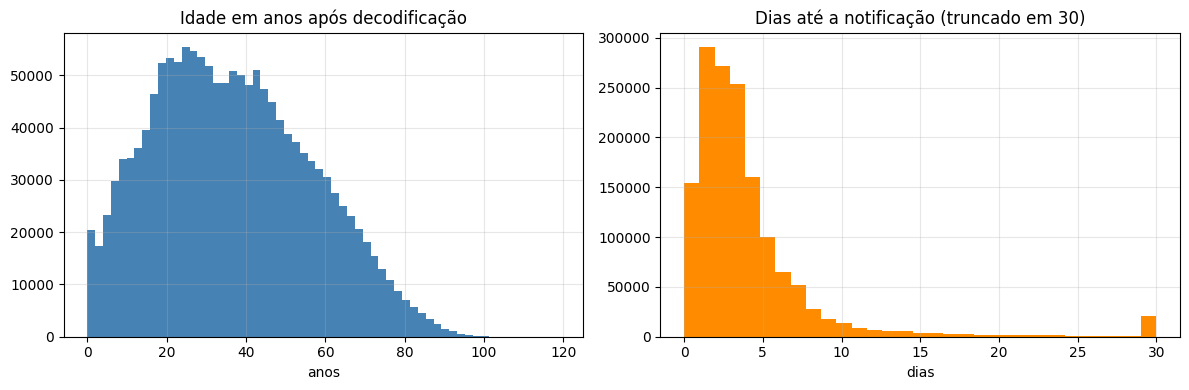

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(sinan.idade_anos.dropna(), bins=60, color="steelblue"); ax[0].set_title("Idade em anos após decodificação"); ax[0].set_xlabel("anos")
ax[1].hist(sinan.dias_ate_notificacao.dropna().clip(upper=30), bins=31, color="darkorange"); ax[1].set_title("Dias até a notificação (truncado em 30)"); ax[1].set_xlabel("dias")
plt.tight_layout(); plt.show()

## 9. Exportação

Três arquivos na camada tratada, ligados por `id_registro`:

- `sinan_dengue_2025_tratado.csv` — uma linha por caso elegível: identificador, datas iniciais, demográficas (código original e versão decodificada), chave territorial, sintomas e comorbidades recodificados, variáveis derivadas, alvo e a marca de possível duplicidade;
- `sinan_dengue_2025_auditoria.csv` — os campos de auditoria (alarme, gravidade, desfecho, laboratoriais, infecção), fora do conjunto preditor;
- `sinan_dengue_2025_tratado_dicionario.csv` — origem e regra de cada coluna exportada.

Uma cópia em parquet acompanha o CSV apenas para acelerar a leitura no notebook de integração.

In [19]:
# ============================================================
# 9. EXPORTAÇÃO
# ============================================================
COLS_SAIDA = (["id_registro","DT_NOTIFIC","DT_SIN_PRI","SEM_NOT","SEM_PRI","NU_ANO","NU_IDADE_N","idade_anos",
               "CS_SEXO","sexo","CS_GESTANT","gestante","CS_RACA","raca","CS_ESCOL_N","escolaridade","ocupacao_cbo",
               "SG_UF","uf_res","ID_MN_RESI","cod_municipio"] + [c+"_bin" for c in SINTOMAS+COMORB]
              + ["dias_ate_notificacao","mes_sintomas","competencia","CLASSI_FIN","alvo","flag_possivel_duplicidade"])
COLS_AUDIT = ["id_registro","CLASSI_FIN","alvo"] + [c for c in todas if decisao[c]["destino"] == "auditoria"]

tratado = sinan[COLS_SAIDA]
tratado.to_csv(ARQ_TRATADO, index=False, date_format="%Y-%m-%d")
tratado.to_parquet(ARQ_TRATADO.with_suffix(".parquet"), index=False)
# auditoria gravada em fluxo: mesmas linhas (sem duplicatas exatas, só elegíveis), sem ocupar memória
t0 = time.time(); inicio = 0; primeiro = True
for bloco in pd.read_csv(ARQ_BRUTO, sep=separador, encoding=encoding, usecols=[c for c in COLS_AUDIT if c not in ("id_registro","alvo")], dtype=str, chunksize=200_000):
    bloco.index = np.arange(inicio, inicio + len(bloco)); inicio += len(bloco)
    bloco = bloco.drop(index=rep[(rep >= bloco.index[0]) & (rep <= bloco.index[-1])])
    bloco = bloco[bloco.CLASSI_FIN.isin(["10","11","12"])]
    bloco.insert(0, "id_registro", bloco.index); bloco.insert(2, "alvo", (bloco.CLASSI_FIN != "10").astype(int))
    bloco.to_csv(ARQ_AUDITORIA, index=False, mode="w" if primeiro else "a", header=primeiro); primeiro = False
print(f"auditoria gravada em {time.time()-t0:.0f} s")

regra = {"id_registro": "posição da linha no arquivo bruto (0 = primeira linha de dados)",
         "idade_anos": "R5: NU_IDADE_N decodificada (4 anos, 3 meses, 2 dias, 1 horas); > 120 -> nulo",
         "sexo": "R4: CS_SEXO M/F; demais -> I", "gestante": "R4: CS_GESTANT 1-4 sim, 5 nao, 6 nao_se_aplica, demais ignorado",
         "raca": "R4: CS_RACA 1 branca, 2 preta, 3 amarela, 4 parda, 5 indigena, demais ignorado",
         "escolaridade": "R4: CS_ESCOL_N decodificada; 9/nulo ignorado; 10 nao_se_aplica", "ocupacao_cbo": "ID_OCUPA_N sem alteração (62% ausente)",
         "uf_res": "SG_UF como texto", "cod_municipio": "R7: ID_MN_RESI com 6 dígitos, texto",
         "dias_ate_notificacao": "R6: DT_NOTIFIC - DT_SIN_PRI em dias; <0 ou >180 -> nulo", "mes_sintomas": "R6: mês de DT_SIN_PRI",
         "competencia": "R6: AAAAMM de DT_SIN_PRI (chave temporal do CNES)", "alvo": "R3: CLASSI_FIN 10 -> 0; 11,12 -> 1",
         "flag_possivel_duplicidade": "R2: 1 se a chave (datas, município, idade, sexo, raça, classificação) se repete; mantida"}
for c in SINTOMAS: regra[c+"_bin"] = f"R4: {c} 1 -> 1, 2 -> 0, demais -> nulo"
for c in COMORB:   regra[c+"_bin"] = f"R4: {c} 1 -> 1, 2 -> 0, 9/nulo -> nulo"
dicio = pd.DataFrame({"coluna": COLS_SAIDA, "dtype": tratado.dtypes.astype(str).values,
                      "origem_regra": [regra.get(c, "coluna original do SINAN, sem alteração") for c in COLS_SAIDA]})
dicio.to_csv(ARQ_DICIONARIO, index=False)
LOG["etapas"]["exportacao"] = {"linhas": int(len(tratado)), "colunas": len(COLS_SAIDA), "tamanho_MB": round(ARQ_TRATADO.stat().st_size/1e6, 1),
                               "auditoria_colunas": len(COLS_AUDIT)}
aud_ids = pd.read_csv(ARQ_AUDITORIA, usecols=["id_registro"]).id_registro
assert len(aud_ids) == len(tratado) and (aud_ids.values == tratado.id_registro.values).all(), "auditoria e base tratada divergem"
print("auditoria alinhada à base tratada:", len(aud_ids), "linhas")
print(json.dumps(LOG["etapas"]["exportacao"], indent=2))
dicio

auditoria gravada em 32 s


auditoria alinhada à base tratada: 1481802 linhas
{
  "linhas": 1481802,
  "colunas": 48,
  "tamanho_MB": 360.7,
  "auditoria_colunas": 73
}


,coluna,dtype,origem_regra
0,id_registro,int64,posição da linha no arquivo bruto (0 = primeir...
1,DT_NOTIFIC,datetime64[us],"coluna original do SINAN, sem alteração"
2,DT_SIN_PRI,datetime64[us],"coluna original do SINAN, sem alteração"
3,SEM_NOT,float32,"coluna original do SINAN, sem alteração"
4,SEM_PRI,float32,"coluna original do SINAN, sem alteração"
5,NU_ANO,float32,"coluna original do SINAN, sem alteração"
6,NU_IDADE_N,float32,"coluna original do SINAN, sem alteração"
7,idade_anos,float32,"R5: NU_IDADE_N decodificada (4 anos, 3 meses, ..."
8,CS_SEXO,category,"coluna original do SINAN, sem alteração"
9,sexo,category,R4: CS_SEXO M/F; demais -> I


## 10. Resumo

Contagens antes e depois e as transformações realizadas. O `sinan_limpeza_log.json` guarda o mesmo conteúdo em formato legível por máquina, para o diário e para o relatório.

In [20]:
# ============================================================
# 10. RESUMO
# ============================================================
LOG["executado_em"] = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")
(ARQ_LOG).write_text(json.dumps(LOG, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
resumo = pd.DataFrame([
    ["linhas no bruto", total, ""],
    ["linhas totalmente duplicadas removidas (R2)", contagem["duplicatas_exatas_removidas"], "hash da linha completa"],
    ["excluídas por classificação (R3)", contagem["excluidos_por_classificacao"], "8 inconclusivo, 0 inválido, nulo"],
    ["base final elegível", contagem["base_final_elegivel"], "CLASSI_FIN 10, 11, 12"],
    ["positivos (alvo = 1)", int(sinan.alvo.sum()), f"{sinan.alvo.mean()*100:.2f}%"],
    ["colunas no bruto", len(todas), ""],
    ["colunas retidas / alvo / auditoria / removidas", f"{(tab_decisao.destino=='retida').sum()} / 1 / {(tab_decisao.destino=='auditoria').sum()} / {(tab_decisao.destino=='removida').sum()}", "R1"],
    ["colunas na base tratada", len(COLS_SAIDA), "originais + derivadas"],
    ["possíveis duplicidades marcadas", LOG["etapas"]["aplicacao"]["possiveis_duplicidades_marcadas"], "mantidas com flag"],
    ["idades inválidas -> nulo", n_idade_invalida, "R5"],
    ["dias até notificação inválidos -> nulo", neg + longo, "R6"],
], columns=["item", "valor", "observação"])
resumo

,item,valor,observação
0,linhas no bruto,1643215,
1,linhas totalmente duplicadas removidas (R2),620,hash da linha completa
2,excluídas por classificação (R3),160793,"8 inconclusivo, 0 inválido, nulo"
3,base final elegível,1481802,"CLASSI_FIN 10, 11, 12"
4,positivos (alvo = 1),37792,2.55%
5,colunas no bruto,121,
6,colunas retidas / alvo / auditoria / removidas,34 / 1 / 70 / 16,R1
7,colunas na base tratada,48,originais + derivadas
8,possíveis duplicidades marcadas,72659,mantidas com flag
9,idades inválidas -> nulo,36,R5
